# 04 — Layer 2b: Machine Learning Models
## Linear Regression · Elastic Net · SVR · Random Forest · XGBoost

### Purpose
Train and evaluate five ML regression models to predict GDP growth
using lagged macroeconomic indicators. 5-fold cross-validation on
train set. Period-by-period evaluation on test set. SHAP explainability
for XGBoost. Compare all models against Layer 2a baseline.

### Input
- `../data/03_panel_instability.csv`

### Output
- `../models/` — 5 trained model .pkl files + scaler.pkl
- `../data/layer2b_results.csv`
- `../data/layer2b_feature_importance.csv`
- 5 diagnostic plots + SHAP plots

### Run after → Run before
`03_layer2a_econometric.ipynb` → `05_layer3_lstm.ipynb`

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os
warnings.filterwarnings("ignore")
os.makedirs("models", exist_ok=True)

from sklearn.linear_model import LinearRegression, ElasticNetCV
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score, KFold
import xgboost as xgb
import joblib

BLUE,AMBER,RED,GREEN,TEAL,GRAY =     "#2E5090","#C9720F","#A32D2D","#3B6D11","#0F6E56","#5F5E5A"

df = pd.read_csv("data/03_panel_instability.csv")
print(f"Loaded: {df.shape} | Countries: {df['COUNTRY'].nunique()}")

feature_cols = [
    "GDP_Growth_lag1",
    "GDP_Growth_rollmean3",
    "Inflation_lag1_log",
    "Exports_lag1",
    "Imports_lag1",
    "Fiscal_Balance_lag1",
    "Current_Account_lag1",
    "Debt_diff_lag1",
    "Expenditure_diff_lag1",
    "Revenue_diff_lag1",
    "Savings_diff_lag1",
    "Investment_diff_lag1",
    "Instability_Index_lag1",
]

df_model = df.dropna(subset=feature_cols+["GDP_Growth"]).copy()
print(f"Model dataset: {df_model.shape}")

Loaded: (5157, 101) | Countries: 175
Model dataset: (4982, 101)


In [27]:
# ── Train/test split + scaling ────────────────────────────────
train = df_model[df_model["YEAR"] <= 2019].copy()
test  = df_model[df_model["YEAR"] >= 2020].copy()

X_train,y_train = train[feature_cols].values, train["GDP_Growth"].values
X_test, y_test  = test[feature_cols].values,  test["GDP_Growth"].values



scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
X_pre_sc   = scaler.transform(X_pre)
joblib.dump(scaler,"models/scaler.pkl")

print(f"Train: {train.shape} | Test: {test.shape}")

Train: (3777, 101) | Test: (1205, 101)


In [28]:
# ── Model definitions ─────────────────────────────────────────
models = {
    "Linear Regression": {"model":LinearRegression(),"scaled":True,"color":GRAY},
    "Elastic Net"      : {"model":ElasticNetCV(l1_ratio=[0.1,0.5,0.7,0.9,1.0],
                              cv=5,max_iter=10000,random_state=42),
                          "scaled":True,"color":TEAL},
    "SVR"              : {"model":SVR(kernel="rbf",C=1.0,epsilon=0.1,gamma="scale"),
                          "scaled":True,"color":AMBER},
    "Random Forest"    : {"model":RandomForestRegressor(n_estimators=300,max_depth=8,
                              min_samples_leaf=5,random_state=42,n_jobs=-1),
                          "scaled":False,"color":GREEN},
    "XGBoost"          : {"model":xgb.XGBRegressor(n_estimators=300,learning_rate=0.05,
                              max_depth=4,subsample=0.8,colsample_bytree=0.8,
                              reg_alpha=0.1,reg_lambda=1.0,random_state=42,verbosity=0),
                          "scaled":False,"color":BLUE},
}
print("Models defined:")
for name in models: print(f"  {name}")

Models defined:
  Linear Regression
  Elastic Net
  SVR
  Random Forest
  XGBoost


In [29]:
from sklearn.base import clone
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np
import joblib
import os
import gc

os.makedirs("models", exist_ok=True)

# Years aligned with X_train and y_train
train_years = train["YEAR"].to_numpy(copy=False)

# Expanding-window validation:
# train on all earlier years, validate on one later year
validation_years = [2015, 2016, 2017, 2018, 2019]
time_splits = []

for validation_year in validation_years:
    train_idx = np.flatnonzero(train_years < validation_year)
    validation_idx = np.flatnonzero(train_years == validation_year)

    if len(train_idx) > 0 and len(validation_idx) > 0:
        time_splits.append((train_idx, validation_idx))

        print(
            f"Fold {validation_year}: "
            f"train={len(train_idx)}, validation={len(validation_idx)}"
        )

trained = {}
cv_results = {}

scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2",
}

for name, cfg in models.items():
    print(f"\nTraining {name}...")

    estimator = clone(cfg["model"])

    # Prevent RF/XGBoost from creating additional parallel workers
    estimator_params = estimator.get_params()

    if "n_jobs" in estimator_params:
        estimator.set_params(n_jobs=1)

    # Scaling is fitted separately inside every CV fold
    if cfg["scaled"]:
        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("model", estimator),
        ])
    else:
        pipeline = Pipeline([
            ("model", estimator),
        ])

    # Run all metrics in one CV operation
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=time_splits,
        scoring=scoring,
        n_jobs=1,
        return_train_score=False,
        error_score="raise",
    )

    cv_rmse = -scores["test_rmse"]
    cv_mae = -scores["test_mae"]
    cv_r2 = scores["test_r2"]

    cv_results[name] = {
        "CV_RMSE": round(cv_rmse.mean(), 3),
        "CV_RMSE_std": round(cv_rmse.std(), 3),
        "CV_MAE": round(cv_mae.mean(), 3),
        "CV_MAE_std": round(cv_mae.std(), 3),
        "CV_R2": round(cv_r2.mean(), 3),
        "CV_R2_std": round(cv_r2.std(), 3),
    }

    # Final fit using all training observations
    pipeline.fit(X_train, y_train)
    trained[name] = pipeline

    filename = name.lower().replace(" ", "_")
    joblib.dump(pipeline, f"models/{filename}.pkl")

    print(
        f"{name:<20} "
        f"RMSE: {cv_rmse.mean():.3f} ± {cv_rmse.std():.3f} | "
        f"MAE: {cv_mae.mean():.3f} | "
        f"R²: {cv_r2.mean():.3f} ± {cv_r2.std():.3f}"
    )

    gc.collect()

cv_results_df = pd.DataFrame(cv_results).T
cv_results_df.to_csv("data/layer2b_cv_results.csv")

print("\nAll models and CV results saved.")
display(cv_results_df.sort_values("CV_RMSE"))

Fold 2015: train=2907, validation=174
Fold 2016: train=3081, validation=174
Fold 2017: train=3255, validation=174
Fold 2018: train=3429, validation=174
Fold 2019: train=3603, validation=174

Training Linear Regression...
Linear Regression    RMSE: 3.459 ± 0.592 | MAE: 2.072 | R²: 0.128 ± 0.180

Training Elastic Net...
Elastic Net          RMSE: 3.455 ± 0.587 | MAE: 2.068 | R²: 0.130 ± 0.177

Training SVR...
SVR                  RMSE: 3.424 ± 0.410 | MAE: 1.855 | R²: 0.149 ± 0.058

Training Random Forest...
Random Forest        RMSE: 3.362 ± 0.640 | MAE: 1.854 | R²: 0.181 ± 0.174

Training XGBoost...
XGBoost              RMSE: 3.389 ± 0.396 | MAE: 1.945 | R²: 0.160 ± 0.111

All models and CV results saved.


,CV_RMSE,CV_RMSE_std,CV_MAE,CV_MAE_std,CV_R2,CV_R2_std
Random Forest,3.362,0.640,1.854,0.268,0.181,0.174
XGBoost,3.389,0.396,1.945,0.246,0.160,0.111
SVR,3.424,0.410,1.855,0.251,0.149,0.058
Elastic Net,3.455,0.587,2.068,0.253,0.130,0.177
Linear Regression,3.459,0.592,2.072,0.255,0.128,0.180


In [31]:
# -- Test set evaluation ---------------------------------------

def eval_period(name, y_true, y_pred, period):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    yt = y_true[mask]
    yp = y_pred[mask]

    if len(yt) == 0:
        return None

    return {
        "Model": name,
        "Period": period,
        "N": len(yt),
        "RMSE": round(
            np.sqrt(mean_squared_error(yt, yp)), 3
        ),
        "MAE": round(mean_absolute_error(yt, yp), 3),
        "R2": round(r2_score(yt, yp), 3),
        "Mean_Actual": round(float(yt.mean()), 2),
        "Mean_Predicted": round(float(yp.mean()), 2),
        "Mean_Error": round(float((yt - yp).mean()), 2),
    }


test_years = test["YEAR"].to_numpy(copy=False)

# Evaluate only years containing observed GDP values
period_masks = {
    "COVID shock (2020)": test_years == 2020,

    "Recovery (2021-22)": np.isin(
        test_years, [2021, 2022]
    ),

    "Observed post-COVID (2023)": test_years == 2023,

    "Observed test (2020-23)": np.isin(
        test_years, [2020, 2021, 2022, 2023]
    ),
}

all_results = []
predictions = {}

# Generate predictions from every fitted pipeline
for name, model_pipeline in trained.items():
    pred_test = model_pipeline.predict(X_test)
    predictions[name] = pred_test

    for period, period_mask in period_masks.items():
        result = eval_period(
            name=name,
            y_true=y_test[period_mask],
            y_pred=pred_test[period_mask],
            period=period,
        )

        if result is not None:
            all_results.append(result)


# Save observed-period evaluation
results_df = pd.DataFrame(all_results)

results_df.to_csv(
    "data/layer2b_results.csv",
    index=False,
)

# Display the main observed test results
period = "Observed test (2020-23)"

print(f"\n-- {period} --")

period_results = (
    results_df[results_df["Period"] == period]
    .sort_values("RMSE")
)

print(
    period_results[
        ["Model", "N", "RMSE", "MAE", "R2"]
    ].to_string(index=False)
)


# -- Save 2024-2026 forecasts separately -----------------------

forecast_mask = np.isin(
    test_years, [2024, 2025, 2026]
)

forecast_df = (
    test.loc[forecast_mask, ["COUNTRY", "YEAR"]]
    .reset_index(drop=True)
)

for name, pred_test in predictions.items():
    forecast_df[name] = pred_test[forecast_mask]

forecast_df.to_csv(
    "data/layer2b_forecasts_2024_2026.csv",
    index=False,
)

print("\nSaved:")
print("  data/layer2b_results.csv")
print("  data/layer2b_forecasts_2024_2026.csv")

print(
    "\nObserved evaluation rows:",
    int(period_masks["Observed test (2020-23)"].sum())
)

print(
    "Forecast rows:",
    int(forecast_mask.sum())
)


-- Observed test (2020-23) --
            Model   N  RMSE   MAE     R2
    Random Forest 692 6.954 4.641  0.064
          XGBoost 692 7.148 4.798  0.011
Linear Regression 692 7.260 4.754 -0.020
      Elastic Net 692 7.260 4.754 -0.020
              SVR 692 7.262 4.675 -0.021

Saved:
  data/layer2b_results.csv
  data/layer2b_forecasts_2024_2026.csv

Observed evaluation rows: 692
Forecast rows: 513


In [ ]:
# -- Feature importance ----------------------------------------

rf_model = trained["Random Forest"].named_steps["model"]
xgb_model = trained["XGBoost"].named_steps["model"]
en_model = trained["Elastic Net"].named_steps["model"]

rf_imp = pd.Series(
    rf_model.feature_importances_,
    index=feature_cols,
    name="RF",
).sort_values(ascending=False)

xgb_imp = pd.Series(
    xgb_model.feature_importances_,
    index=feature_cols,
    name="XGB",
).sort_values(ascending=False)

# Elastic Net coefficients correspond to standardized features
en_coef = pd.Series(
    en_model.coef_,
    index=feature_cols,
    name="EN",
).sort_values(key=np.abs, ascending=False)

print("Random Forest top 5:")
print(rf_imp.head(5).round(4))

print("\nXGBoost top 5:")
print(xgb_imp.head(5).round(4))

print("\nElastic Net non-zero coefficients:")
print(en_coef[en_coef != 0].round(4))

importance_df = pd.concat(
    [rf_imp, xgb_imp, en_coef],
    axis=1,
)

importance_df.index.name = "Feature"

importance_df.to_csv(
    "data/layer2b_feature_importance.csv"
)

print("\nSaved: data/layer2b_feature_importance.csv")

Random Forest top 5:
GDP_Growth_lag1         0.3828
GDP_Growth_rollmean3    0.2565
Exports_lag1            0.0585
Imports_lag1            0.0525
Inflation_lag1_log      0.0358
Name: RF, dtype: float64

XGBoost top 5:
GDP_Growth_rollmean3     0.1411
GDP_Growth_lag1          0.1339
Expenditure_diff_lag1    0.0873
Savings_diff_lag1        0.0813
Investment_diff_lag1     0.0778
Name: XGB, dtype: float32

Elastic Net non-zero coefficients:
GDP_Growth_rollmean3      1.9237
Savings_diff_lag1         0.5129
Imports_lag1              0.4794
Instability_Index_lag1    0.4325
Investment_diff_lag1     -0.3909
Exports_lag1             -0.3602
Revenue_diff_lag1        -0.2943
Expenditure_diff_lag1    -0.2669
Debt_diff_lag1           -0.2504
Inflation_lag1_log       -0.2465
GDP_Growth_lag1           0.2093
Fiscal_Balance_lag1      -0.1338
Current_Account_lag1     -0.1022
Name: EN, dtype: float64

Saved: data/layer2b_feature_importance.csv


Random Forest: historical GDP growth dominates, contributing roughly 77% combined importance.
XGBoost: importance is more distributed across GDP history and fiscal variables.
Elastic Net: coefficients indicate direction because inputs were standardized:Positive: higher rolling GDP growth, imports and lagged instability
Negative: expenditure changes, fiscal balance, exports, inflation and debt changes

Maximum reconstruction difference: 3.0517578e-05


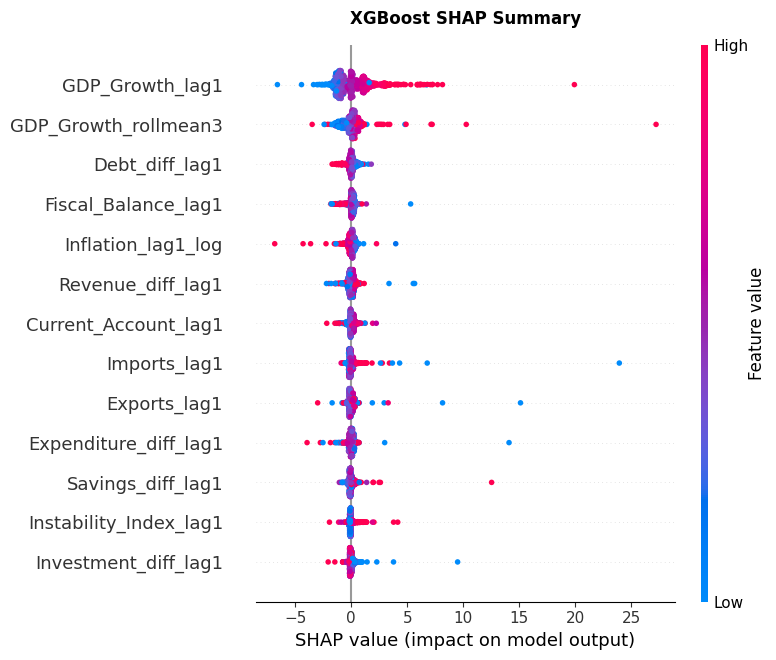

SHAP observations used: 1000
Saved: layer2b_shap_summary.png
Saved: models/shap_values_xgboost_train.npy
Saved: models/shap_base_values_xgboost_train.npy


In [ ]:
# -- Native XGBoost SHAP values --------------------------------

import xgboost as xgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

# Extract XGBoost from the fitted pipeline
xgb_model = trained["XGBoost"].named_steps["model"]

# Sample training rows to limit memory use
rng = np.random.default_rng(42)
sample_size = min(1000, len(X_train))

sample_indices = rng.choice(
    len(X_train),
    size=sample_size,
    replace=False
)

X_shap = pd.DataFrame(
    X_train[sample_indices],
    columns=feature_cols
)

# Create XGBoost's native data structure
dmat = xgb.DMatrix(
    X_shap,
    feature_names=feature_cols
)

# Native SHAP contributions
# Last column is the expected/base value
contributions = xgb_model.get_booster().predict(
    dmat,
    pred_contribs=True
)

shap_values = contributions[:, :-1]
base_values = contributions[:, -1]

# Validation: SHAP contributions should reconstruct predictions
native_predictions = xgb_model.predict(X_shap)
reconstructed_predictions = (
    shap_values.sum(axis=1) + base_values
)

print(
    "Maximum reconstruction difference:",
    np.max(
        np.abs(
            native_predictions - reconstructed_predictions
        )
    )
)

# Save calculated values
np.save(
    "models/shap_values_xgboost_train.npy",
    shap_values
)

np.save(
    "models/shap_base_values_xgboost_train.npy",
    base_values
)

X_shap.to_csv(
    "data/shap_xgboost_sample.csv",
    index=False
)

# SHAP summary plot
plt.figure(figsize=(10, 7))

shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_cols,
    max_display=len(feature_cols),
    show=False
)

plt.title(
    "XGBoost SHAP Summary",
    fontweight="bold",
    pad=15
)

plt.tight_layout()

plt.savefig(
    "layer2b_shap_summary.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print(f"SHAP observations used: {sample_size}")
print("Saved: layer2b_shap_summary.png")
print("Saved: models/shap_values_xgboost_train.npy")
print("Saved: models/shap_base_values_xgboost_train.npy")

Features are ordered by mean absolute SHAP importance.
GDP_Growth_lag1 and GDP_Growth_rollmean3 are the strongest predictors.
Positive SHAP values increase predicted GDP growth; negative values reduce it.
Red means a high feature value; blue means a low value.
High lagged GDP growth generally increases predictions.
High debt changes, poor fiscal balance, high inflation and expenditure changes often reduce predictions.
Instability_Index_lag1 has relatively little influence and is correctly lagged.

In [ ]:
shap_check = X_shap.copy()
shap_check["SHAP_GDP_rollmean3"] = shap_values[
    :, feature_cols.index("GDP_Growth_rollmean3")
]

shap_check.nlargest(
    10, "SHAP_GDP_rollmean3"
)[
    ["GDP_Growth_rollmean3", "SHAP_GDP_rollmean3"]
]

,GDP_Growth_rollmean3,SHAP_GDP_rollmean3
796,66.394333,27.201221
611,23.373333,10.258668
730,23.412000,7.219355
613,21.255667,7.118392
850,35.242333,4.888307
135,-16.570667,4.790719
189,16.247333,3.430981
209,18.248667,3.248942
53,16.134000,2.884215
794,18.492333,2.732293


In [ ]:
df.loc[
    df["GDP_Growth_rollmean3"] > 25,
    ["COUNTRY", "YEAR", "GDP_Growth", "GDP_Growth_lag1",
     "GDP_Growth_rollmean3"]
].sort_values("GDP_Growth_rollmean3", ascending=False)

,COUNTRY,YEAR,GDP_Growth,GDP_Growth_lag1,GDP_Growth_rollmean3
1491,"Equatorial Guinea, Republic of",1998,24.815,147.973,75.720333
1492,"Equatorial Guinea, Republic of",1999,26.395,24.815,75.155333
1493,"Equatorial Guinea, Republic of",2000,110.505,26.395,66.394333
1495,"Equatorial Guinea, Republic of",2002,19.621,60.023,65.641000
1496,"Equatorial Guinea, Republic of",2003,14.455,19.621,63.383000
1494,"Equatorial Guinea, Republic of",2001,60.023,110.505,53.905000
1991,Guyana,2025,19.309,43.776,46.959667
1989,Guyana,2023,33.769,63.334,42.291333
561,Bosnia and Herzegovina,1997,22.853,62.178,41.437000
1490,"Equatorial Guinea, Republic of",1997,147.973,52.678,39.594000
